# Quantitative Modeling of AI Inference Energy Consumption

This notebook implements the simulation described in Chapter 4 of the thesis.

**Block 0**: System variables and constants. Set `arrival_mode` (`nhpp_only` or `hybrid`) and `strategy_mode` (`Static`, `Conservative`, `Aggressive`) here.

**Block 1**: Arrival process. Generates the NHPP base and the Pareto burst overlay, then writes whichever one is selected into `lambda_15min`.

**Block 2**: Capacity, utilisation, and cold-start lag. Reports SLA violations.

**Block 3**: Three-state GPU distribution.

**Block 4**: Energy accounting (kWh per state, daily totals).

**Block 6**: Strategy x arrival-process comparison table (matches Table 4.2 in the thesis).

**Block 5**: Country carbon-intensity comparison.


In [17]:
# --- Block 0: System Variables & Constants (15-Min Resolution) ---
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility: fix the RNG seed so every run produces identical numbers
np.random.seed(42)

# @title Simulation Configuration

# --- Queueing parameters ---
# mu = 0.2 req/s: one GPU processes one request every ~5 seconds.
# This is consistent with measured throughput for large LLM inference
# on modern accelerators (Özcan et al., 2025).
mu = 0.2  # Service rate per GPU (requests/second)

# --- Workload parameters ---
# The diurnal SHAPE is derived from the BurstGPT dataset (Chen et al., 2023),
# which recorded real hourly LLM request traffic. Values are normalized
# so that peak hour = 1.0.
_burstgpt_shape = np.array([
    0.20, 0.15, 0.10, 0.09, 0.09, 0.13, 0.22, 0.38,
    0.55, 0.70, 0.82, 0.90, 0.95, 1.00, 0.98, 0.92,
    0.86, 0.84, 0.79, 0.69, 0.56, 0.45, 0.35, 0.26
], dtype=float)

# The SCALE is derived from mu and a target cluster load at peak hour.
# We choose c_peak = 200 GPUs active at peak (out of 256), which represents
# a realistic high-load scenario. The conservative provisioning formula is:
#   c = lambda / (0.78 * mu)  =>  lambda_peak = 0.78 * mu * c_peak
c_peak      = 200                      # GPUs active at peak hour
lambda_peak = 0.78 * mu * c_peak      # = 31.2 req/s at peak

T_day         = 24
lambda_hourly = _burstgpt_shape * lambda_peak  # req/s, 24 hourly values

# Create a 96-step array (every 15 minutes = 0.25 hours)
hours_96 = np.arange(0, 24, 0.25)
hours_24 = np.arange(24)

# Linear interpolation to create realistic sub-hourly demand (NHPP base)
lambda_15min_nhpp = np.interp(hours_96, hours_24, lambda_hourly)
max_lam = lambda_15min_nhpp.max()

# This is the variable the rest of the notebook reads. By default we
# start with the NHPP-only base; Block 1 may overwrite it with the
# hybrid (NHPP + Pareto bursts) version depending on arrival_mode.
lambda_15min = lambda_15min_nhpp.copy()

# --- Arrival process toggle ---
# "nhpp_only"  : just the smooth diurnal curve
# "hybrid"     : NHPP base + Pareto burst overlay (set in Block 1)
arrival_mode = 'hybrid'  # @param ["nhpp_only", "hybrid"]

# --- Power parameters ---
P_idle           = 140
P_execution_idle = 220
P_maxTDP         = 1000
P_active_avg     = 450
PUE              = 1.08

# --- Environmental parameters ---
gamma = 0.05

# --- Physical cluster size ---
total_gpus = 256

# --- Provisioning Strategy ---
strategy_mode = 'Aggressive'  # @param ["Static", "Conservative", "Aggressive"]

def scale_in_pods(c_target):
    return np.ceil(c_target / 8) * 8

# Note on the np.minimum cap: without it, the ceiling-to-multiple-of-8
# operation can produce e.g. 264 GPUs even though we only have 256.
c_static       = np.full(96, total_gpus)
c_conservative = np.minimum(scale_in_pods(lambda_15min / (0.78 * mu)), total_gpus)
c_aggressive   = np.minimum(scale_in_pods(lambda_15min / (0.95 * mu)), total_gpus)

if strategy_mode == "Static":
    c_active = c_static
elif strategy_mode == "Conservative":
    c_active = c_conservative
elif strategy_mode == "Aggressive":
    c_active = c_aggressive

print("Block 0 initialised (15-minute resolution).")
print(f"  Arrival mode:    {arrival_mode}")
print(f"  Strategy:        {strategy_mode}")
print(f"  Cluster size:    {total_gpus} GPUs")
print(f"  mu:              {mu} req/s")
print(f"  lambda_peak:     {lambda_peak:.1f} req/s  (c_peak={c_peak} GPUs at 0.78 utilisation)")
print(f"  lambda_mean:     {lambda_hourly.mean():.1f} req/s")


Block 0 initialised (15-minute resolution).
  Arrival mode:    hybrid
  Strategy:        Aggressive
  Cluster size:    256 GPUs
  mu:              0.2 req/s
  lambda_peak:     31.2 req/s  (c_peak=200 GPUs at 0.78 utilisation)
  lambda_mean:     16.9 req/s


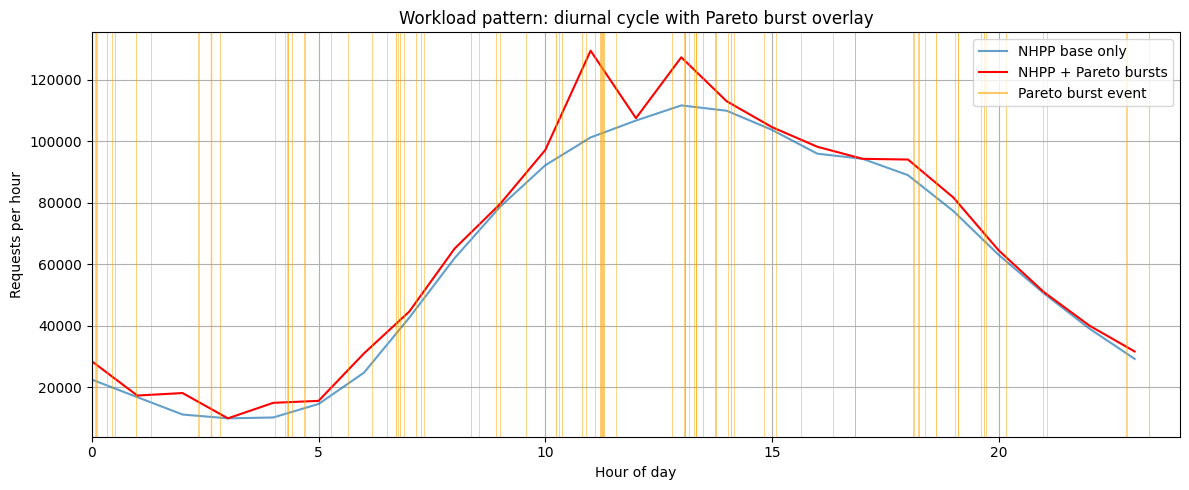

NHPP arrivals:      1457164
Burst arrivals:     102047
Hybrid arrivals:    1559211
Burst events:       81
Largest burst:      27,007 requests
Active lambda(t):   hybrid
  max:  57.37 req/s
  mean: 18.05 req/s


In [ ]:
# --- Block 1: Arrival Rate / Workload ---
import numpy as np
import matplotlib.pyplot as plt

def daily_intensity(t):
    hour = int(t) % 24
    return lambda_hourly[hour]

def simulate_nhpp(lambda_func, max_lambda, T):
    """Thinning algorithm for an NHPP with rate function lambda_func over [0, T] hours."""
    times, t = [], 0
    while t < T:
        t += np.random.exponential(1 / (max_lambda * 3600))
        if t < T and np.random.rand() <= lambda_func(t) / max_lambda:
            times.append(t)
    return times

def simulate_pareto_bursts(shape, T, burst_rate_per_hour=2.0):
    """Generate Pareto-distributed burst events at burst_rate_per_hour
    events per hour over a window of T hours.

    Each burst event spawns floor((X + 1) * lambda_peak * 10) requests,
    where X ~ Pareto(shape), all arriving within a 0.01-hour (~36 second)
    window. Returns (arrival_times, burst_event_times, burst_sizes).
    """
    times, burst_times, burst_sizes = [], [], []
    t = 0
    while t < T:
        t += np.random.exponential(1.0 / burst_rate_per_hour)
        if t < T:
            burst_size = int((np.random.pareto(shape) + 1) * int(lambda_peak * 10))
            burst_times.append(t)
            burst_sizes.append(burst_size)
            for _ in range(burst_size):
                times.append(t + np.random.uniform(0, 0.01))
    return times, burst_times, burst_sizes

def bin_to_15min_rate(arrivals, num_steps=96, step_hours=0.25):
    """Convert a list of arrival times (in hours) to a rate array (req/s)
    binned into num_steps intervals of step_hours each."""
    binned = np.zeros(num_steps)
    seconds_per_step = step_hours * 3600
    for t_arr in arrivals:
        bin_idx = int(t_arr / step_hours)
        if 0 <= bin_idx < num_steps:
            binned[bin_idx] += 1.0 / seconds_per_step
    return binned

# Generate arrivals
base_arrivals  = simulate_nhpp(daily_intensity, max_lam, T_day)
burst_arrivals, burst_times, burst_sizes = simulate_pareto_bursts(
       shape=1.2, T=T_day, burst_rate_per_hour=3.
)
hybrid_arrivals = sorted(base_arrivals + burst_arrivals)

# Build the hybrid lambda(t) at 15-min resolution
lambda_15min_hybrid = bin_to_15min_rate(hybrid_arrivals)

# Switch lambda_15min depending on which arrival process we're studying
if arrival_mode == 'hybrid':
    lambda_15min = lambda_15min_hybrid
    c_conservative = np.minimum(scale_in_pods(lambda_15min / (0.78 * mu)), total_gpus)
    c_aggressive   = np.minimum(scale_in_pods(lambda_15min / (0.95 * mu)), total_gpus)
    if strategy_mode == "Conservative":
        c_active = c_conservative
    elif strategy_mode == "Aggressive":
        c_active = c_aggressive
    elif strategy_mode == "Static":
        c_active = c_static
else:
    lambda_15min = lambda_15min_nhpp.copy()

# Visualisation: hourly request counts
hours = np.arange(24)
requests_nhpp   = [len([t for t in base_arrivals  if h <= t < h + 1]) for h in hours]
requests_hybrid = [len([t for t in hybrid_arrivals if h <= t < h + 1]) for h in hours]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hours, requests_nhpp,   label='NHPP base only', alpha=0.7)
ax.plot(hours, requests_hybrid, label='NHPP + Pareto bursts',
        color='red', linewidth=1.5)

# Mark each burst event with a vertical line, sized by burst magnitude
for bt, bs in zip(burst_times, burst_sizes):
    ax.axvline(x=bt, color='orange', alpha=0.6,
               linewidth=0.5 + (bs / max(burst_sizes)) * 3)

# Add a single legend entry for burst markers
ax.axvline(x=-1, color='orange', alpha=0.6, linewidth=1.5, label='Pareto burst event')

ax.set_title('Workload pattern: diurnal cycle with Pareto burst overlay')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Requests per hour')
ax.set_xlim(0, 24)
ax.legend()
ax.grid(True)
plt.tight_layout()
fig.savefig(FIG_DIR / "workload_pattern.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"NHPP arrivals:      {len(base_arrivals)}")
print(f"Burst arrivals:     {len(burst_arrivals)}")
print(f"Hybrid arrivals:    {len(hybrid_arrivals)}")
print(f"Burst events:       {len(burst_times)}")
print(f"Largest burst:      {max(burst_sizes):,} requests")
print(f"Active lambda(t):   {arrival_mode}")
print(f"  max:  {lambda_15min.max():.2f} req/s")
print(f"  mean: {lambda_15min.mean():.2f} req/s")

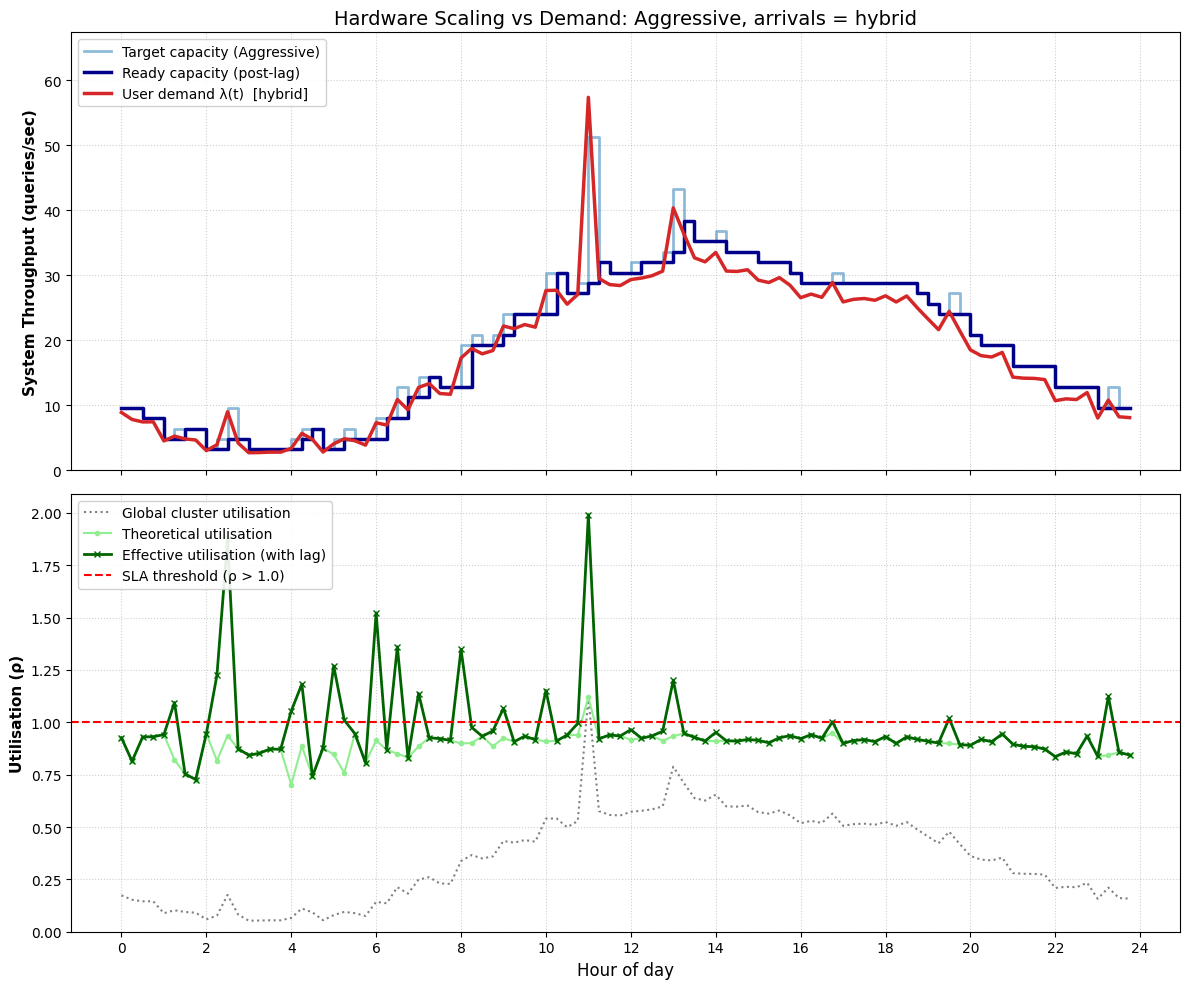


--- Strategy Results: Aggressive, arrivals = hybrid ---
Mean effective utilisation: 0.969
Max  effective utilisation: 1.992
SLA violations detected in 18 of 96 intervals.


In [ ]:
# --- Block 2: Capacity, Utilisation, and Cold-Start Lag (15-Min) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Real-world hardware lag (exactly 1 time step = 15 min for a scale-up).
#    Scale-down is treated as instantaneous.
c_ready = np.zeros(96)
c_ready[0] = c_active[0]
for t in range(1, 96):
    # If scaling UP:    min keeps c_ready at the previous (lower) state for 1 step
    # If scaling DOWN:  min instantly adopts the new (lower) state
    c_ready[t] = np.minimum(c_active[t], c_active[t-1])

# 2. Convert servers to throughput (queries per second)
capacity_target_qps = c_active * mu
capacity_ready_qps  = c_ready  * mu
demand_qps          = lambda_15min

# 3. Utilisation calculations (safe against capacity_ready_qps == 0)
rho_theoretical = np.where(capacity_target_qps > 0,
                           lambda_15min / np.maximum(capacity_target_qps, 1e-9), 0.0)
rho_effective   = np.where(capacity_ready_qps  > 0,
                           lambda_15min / np.maximum(capacity_ready_qps,  1e-9), 0.0)
global_rho_t    = lambda_15min / (total_gpus * mu)

# 4. Visualisation: two-panel chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.set_ylabel('System Throughput (queries/sec)', fontsize=11, fontweight='bold')
ax1.step(hours_96, capacity_target_qps, where='post', color='tab:blue', linewidth=2, alpha=0.5,
         label=f'Target capacity ({strategy_mode})')
ax1.step(hours_96, capacity_ready_qps, where='post', color='darkblue', linewidth=2.5,
         label='Ready capacity (post-lag)')
ax1.plot(hours_96, demand_qps, color='tab:red', linestyle='-', linewidth=2.5,
         label=f'User demand \u03BB(t)  [{arrival_mode}]')
ax1.set_ylim(0, max(capacity_target_qps.max(), demand_qps.max()) + 10)
ax1.set_title(f'Hardware Scaling vs Demand: {strategy_mode}, arrivals = {arrival_mode}', fontsize=14)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_xlabel('Hour of day', fontsize=12)
ax2.set_ylabel('Utilisation (\u03C1)', fontsize=11, fontweight='bold')
ax2.plot(hours_96, global_rho_t,    color='grey',       linestyle=':',  linewidth=1.5,
         label='Global cluster utilisation')
ax2.plot(hours_96, rho_theoretical, color='lightgreen', marker='.',
         linestyle='-',  linewidth=1.5, label='Theoretical utilisation')
ax2.plot(hours_96, rho_effective,   color='darkgreen',  marker='x', markersize=4,
         linestyle='-',  linewidth=2,   label='Effective utilisation (with lag)')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5,
            label='SLA threshold (\u03C1 > 1.0)')
ax2.set_ylim(0, max(1.3, rho_effective.max() * 1.05))
ax2.set_xticks(np.arange(0, 25, 2))
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig.savefig(FIG_DIR / "capacity_utilisation_cold_start.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# --- SLA violation check ---
print(f"\n--- Strategy Results: {strategy_mode}, arrivals = {arrival_mode} ---")
overloaded_steps = np.where(rho_effective > 1)[0]
print(f"Mean effective utilisation: {np.mean(rho_effective):.3f}")
print(f"Max  effective utilisation: {np.max(rho_effective):.3f}")
if len(overloaded_steps) == 0:
    print("System stable: headroom absorbed the cold-start lag and any bursts.")
else:
    print(f"SLA violations detected in {len(overloaded_steps)} of 96 intervals.")


```markdown
# Block 3: GPU States.  GPU states introduces latency ->
When utilized: x "active inference state" and 1-x "execution idle"
When not utilization, assume execution idle.
Once you have ratios of everything, we can use that for next step. Graph the ratios on a column graph. Proportional colors of each state.

```

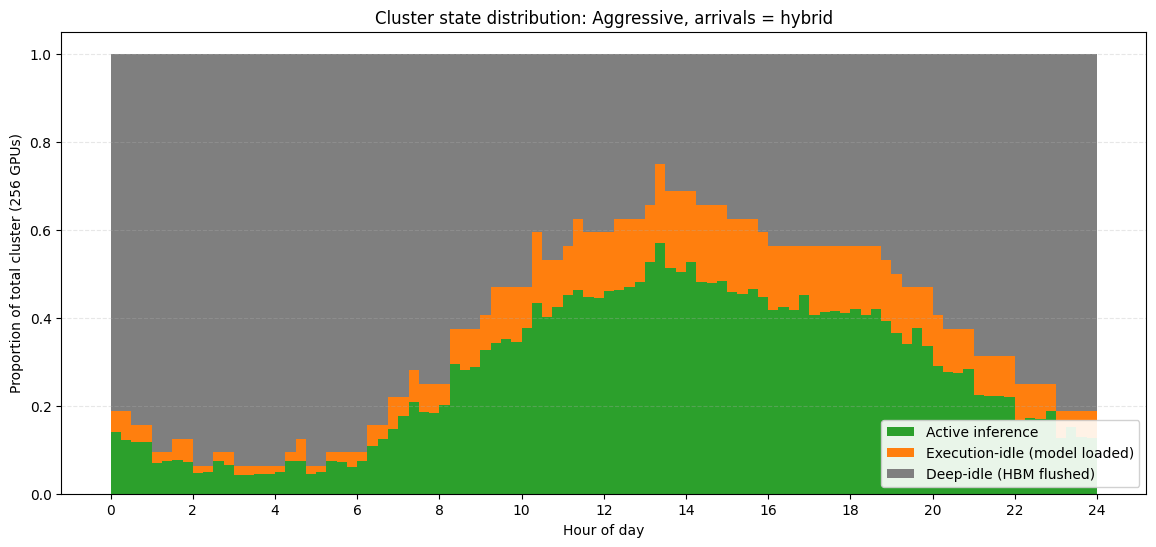

--- Daily state averages: Aggressive, hybrid ---
  Active inference:   27.3%
  Execution-idle:      9.4%
  Deep-idle:          63.3%


In [ ]:
# --- Block 3: GPU State Distribution (15-Min Resolution) ---
import numpy as np
import matplotlib.pyplot as plt

# When rho_effective > 1 (SLA violation), the cluster is over capacity.
# For the state breakdown we cap at 1.0 (the cluster cannot have a fractional
# active count above its size). The SLA violation is reported separately
# in Block 2.
rho_state = np.minimum(rho_effective, 1.0)

# 1. Physical number of GPUs in each state per 15-min step
gpus_active     = c_ready * rho_state * (1 - 0.197)
gpus_exec_idle  = c_ready * ((rho_state * 0.197) + (1 - rho_state))
gpus_deep_idle  = total_gpus - c_ready

# 2. Cluster proportions (0.0 to 1.0)
active_ratio          = gpus_active    / total_gpus
execution_idle_ratio  = gpus_exec_idle / total_gpus
deep_idle_ratio       = gpus_deep_idle / total_gpus

# 3. Stacked bar chart (15-min steps)
plt.figure(figsize=(14, 6))
plt.bar(hours_96, active_ratio, width=0.25, label='Active inference',
        color='#2ca02c', align='edge')
plt.bar(hours_96, execution_idle_ratio, bottom=active_ratio, width=0.25,
        label='Execution-idle (model loaded)', color='#ff7f0e', align='edge')
plt.bar(hours_96, deep_idle_ratio,
        bottom=active_ratio + execution_idle_ratio, width=0.25,
        label='Deep-idle (HBM flushed)', color='#7f7f7f', align='edge')

plt.title(f'Cluster state distribution: {strategy_mode}, arrivals = {arrival_mode}')
plt.xlabel('Hour of day')
plt.ylabel(f'Proportion of total cluster ({total_gpus} GPUs)')
plt.xticks(np.arange(0, 25, 2))
plt.ylim(0, 1.05)
plt.legend(loc='lower right', framealpha=0.9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(FIG_DIR / "gpu_state_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()
plt.close()

# 4. Daily averages
print(f"--- Daily state averages: {strategy_mode}, {arrival_mode} ---")
print(f"  Active inference:  {np.mean(active_ratio)*100:5.1f}%")
print(f"  Execution-idle:    {np.mean(execution_idle_ratio)*100:5.1f}%")
print(f"  Deep-idle:         {np.mean(deep_idle_ratio)*100:5.1f}%")


```markdown
### Block 4: Energiförbrukning
Beräkning av den totala energiförbrukningen baserat på GPU-tillstånden, antal aktiva enheter och PUE.
```

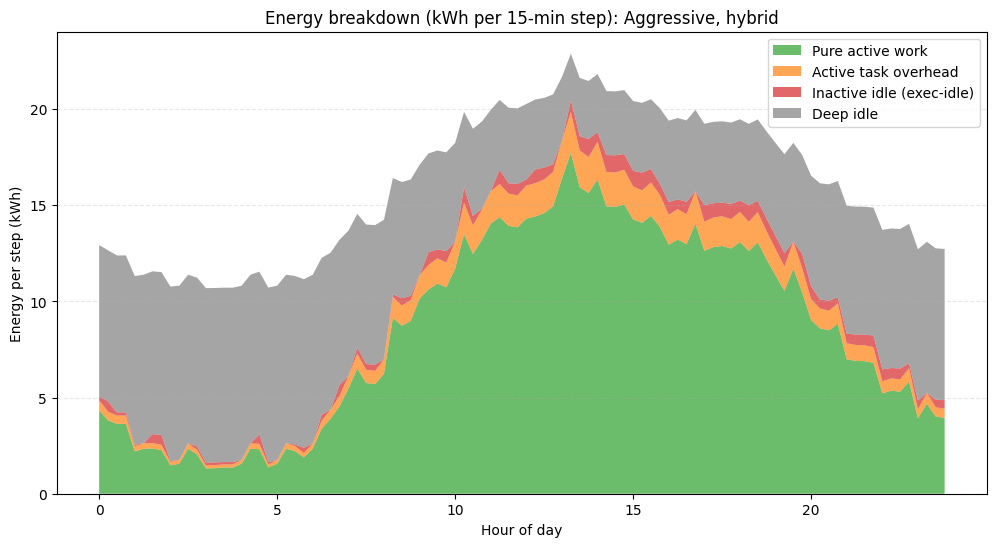

--- Daily energy summary: Aggressive, hybrid ---
Total daily energy:      1540.51 kWh
  Pure active work:       815.46 kWh ( 52.9%)
  Active task overhead:    97.81 kWh (  6.3%)
  Inactive idle:           39.07 kWh (  2.5%)
  Deep idle:              588.17 kWh ( 38.2%)

--- Efficiency metrics ---
Workload efficiency     (work / active state):   89.3%
Provisioning efficiency (work / total energy):   52.9%

Ideal energy (PUE=1.0, no idle): 755.06 kWh
Total waste vs ideal:            785.45 kWh


In [ ]:
# --- Block 4: Detailed Energy Analysis ---
import numpy as np
import matplotlib.pyplot as plt

# Use rho_state (clipped at 1.0) for the energy partition, since when
# rho_effective > 1 the cluster is in SLA violation and physically all
# ready GPUs are active.
rho_state = np.minimum(rho_effective, 1.0)

# Power per 15-min step (Watts before PUE)
pure_active_power     = gpus_active * P_active_avg
active_overhead_power = c_ready * rho_state * 0.197 * P_execution_idle
inactive_idle_power   = c_ready * (1 - rho_state) * P_execution_idle
deep_idle_power       = gpus_deep_idle * P_idle

# Convert to kWh per 15-min step (multiply by 0.25 h, divide by 1000)
energy_pure_work       = (pure_active_power     * PUE * 0.25) / 1000
energy_active_overhead = (active_overhead_power * PUE * 0.25) / 1000
energy_inactive_idle   = (inactive_idle_power   * PUE * 0.25) / 1000
energy_deep_idle       = (deep_idle_power       * PUE * 0.25) / 1000

energy_total = (energy_pure_work + energy_active_overhead
                + energy_inactive_idle + energy_deep_idle)

# Ideal scenario: only pure work, PUE = 1.0
energy_ideal = (pure_active_power * 1.0 * 0.25) / 1000

# Visualisation
plt.figure(figsize=(12, 6))
plt.stackplot(hours_96,
              energy_pure_work, energy_active_overhead,
              energy_inactive_idle, energy_deep_idle,
              labels=['Pure active work', 'Active task overhead',
                      'Inactive idle (exec-idle)', 'Deep idle'],
              colors=['#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f'],
              alpha=0.7)
plt.title(f'Energy breakdown (kWh per 15-min step): {strategy_mode}, {arrival_mode}')
plt.xlabel('Hour of day')
plt.ylabel('Energy per step (kWh)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
fig.savefig(FIG_DIR / "energy_breakdown_by_state.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Aggregate statistics
total_kwh    = np.sum(energy_total)
work_kwh     = np.sum(energy_pure_work)
overhead_kwh = np.sum(energy_active_overhead)
idle_kwh     = np.sum(energy_inactive_idle)
deep_kwh     = np.sum(energy_deep_idle)

print(f"--- Daily energy summary: {strategy_mode}, {arrival_mode} ---")
print(f"Total daily energy:      {total_kwh:7.2f} kWh")
print(f"  Pure active work:      {work_kwh:7.2f} kWh ({(work_kwh/total_kwh)*100:5.1f}%)")
print(f"  Active task overhead:  {overhead_kwh:7.2f} kWh ({(overhead_kwh/total_kwh)*100:5.1f}%)")
print(f"  Inactive idle:         {idle_kwh:7.2f} kWh ({(idle_kwh/total_kwh)*100:5.1f}%)")
print(f"  Deep idle:             {deep_kwh:7.2f} kWh ({(deep_kwh/total_kwh)*100:5.1f}%)")

# Two efficiency metrics, separated as discussed in Ch 5:
#   - Workload efficiency: how much of "active GPU time" is actually work
#   - Provisioning efficiency: how much of total energy is actually work
active_state_total = work_kwh + overhead_kwh
print(f"\n--- Efficiency metrics ---")
print(f"Workload efficiency     (work / active state):  "
      f"{(work_kwh/active_state_total)*100:5.1f}%")
print(f"Provisioning efficiency (work / total energy):  "
      f"{(work_kwh/total_kwh)*100:5.1f}%")

ideal_total_kwh = np.sum(energy_ideal)
print(f"\nIdeal energy (PUE=1.0, no idle): {ideal_total_kwh:.2f} kWh")
print(f"Total waste vs ideal:            {total_kwh - ideal_total_kwh:.2f} kWh")


In [22]:
# --- Block 6: Strategy x Arrival Process Comparison ---
# Re-runs the simulation across all 6 combinations and prints a summary
# table matching Table 4.2 in the thesis.
import numpy as np

def run_one(lambda_arr, c_active_arr):
    # Cold-start lag
    c_r = np.zeros(96)
    c_r[0] = c_active_arr[0]
    for t in range(1, 96):
        c_r[t] = np.minimum(c_active_arr[t], c_active_arr[t-1])

    cap = c_r * mu
    rho_eff = np.where(cap > 0, lambda_arr / np.maximum(cap, 1e-9), 0.0)
    rho_s = np.minimum(rho_eff, 1.0)

    g_active     = c_r * rho_s * (1 - 0.197)
    e_pure       = (g_active * P_active_avg * PUE * 0.25) / 1000
    e_overhead   = (c_r * rho_s * 0.197 * P_execution_idle * PUE * 0.25) / 1000
    e_inactive   = (c_r * (1 - rho_s) * P_execution_idle * PUE * 0.25) / 1000
    e_deep       = ((total_gpus - c_r) * P_idle * PUE * 0.25) / 1000
    e_total      = e_pure + e_overhead + e_inactive + e_deep

    return {
        'total': float(np.sum(e_total)),
        'pure':  float(np.sum(e_pure)),
        'oh':    float(np.sum(e_overhead)),
        'inact': float(np.sum(e_inactive)),
        'deep':  float(np.sum(e_deep)),
        'mean_rho': float(np.mean(rho_eff)),
        'max_rho':  float(np.max(rho_eff)),
        'sla_viol': int(np.sum(rho_eff > 1.0)),
    }

# Re-derive provisioning arrays for both arrival processes
def provisioning(lambda_arr):
    return {
        'Static':       np.full(96, total_gpus),
        'Conservative': np.minimum(scale_in_pods(lambda_arr / (0.78 * mu)), total_gpus),
        'Aggressive':   np.minimum(scale_in_pods(lambda_arr / (0.95 * mu)), total_gpus),
    }

results = {'nhpp_only': {}, 'hybrid': {}}
for am, l_arr in [('nhpp_only', lambda_15min_nhpp), ('hybrid', lambda_15min_hybrid)]:
    prov = provisioning(l_arr)
    for s in ['Static', 'Conservative', 'Aggressive']:
        results[am][s] = run_one(l_arr, prov[s])

# Print comparison table (matches Ch 4 Table 4.2)
col_w = 14
label_w = 16

# Header
print(f"{'':<{label_w}}"
      f"{'NHPP only':^{col_w*3}} | {'NHPP + bursts':^{col_w*3}}")

print(f"{'':<{label_w}}"
      f"{'Static':>{col_w}}{'Conserv.':>{col_w}}{'Aggress.':>{col_w}} | "
      f"{'Static':>{col_w}}{'Conserv.':>{col_w}}{'Aggress.':>{col_w}}")

print('-' * (label_w + col_w*6 + 3))

# Rows
for metric, label in [
    ('total','Total kWh'),
    ('pure','Pure work'),
    ('oh','Overhead'),
    ('inact','Inactive idle'),
    ('deep','Deep idle'),
    ('mean_rho','Mean rho'),
    ('max_rho','Max rho'),
    ('sla_viol','SLA viol /96')
]:
    row = f"{label:<{label_w}}"
    
    for am in ['nhpp_only', 'hybrid']:
        for s in ['Static', 'Conservative', 'Aggressive']:
            v = results[am][s][metric]
            
            if metric in ('mean_rho', 'max_rho'):
                row += f"{v:>{col_w}.2f}"
            elif metric == 'sla_viol':
                row += f"{v:>{col_w}d}"
            else:
                row += f"{v:>{col_w}.1f}"
        
        if am == 'nhpp_only':
            row += " |"
    
    print(row)


                                NHPP only                  |               NHPP + bursts               
                        Static      Conserv.      Aggress. |         Static      Conserv.      Aggress.
-------------------------------------------------------------------------------------------------------
Total kWh               1864.4        1562.5        1522.8 |        1890.2        1588.1        1540.5
Pure work                791.6         791.6         791.0 |         842.1         830.8         815.5
Overhead                  94.9          94.9          94.9 |         101.0          99.6          97.8
Inactive idle            977.9         147.7          39.7 |         947.1         139.1          39.1
Deep idle                  0.0         528.3         597.2 |           0.0         518.6         588.2
Mean rho                  0.33          0.75          0.91 |          0.35          0.79          0.97
Max rho                   0.61          0.86          1.06 |          

In [23]:
import pandas as pd
import requests
import io

csv_url = "https://ourworldindata.org/grapher/carbon-intensity-electricity.csv?v=1&csvType=full&useColumnShortNames=false"

# Define a header to mimic a real browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Download the content using requests
response = requests.get(csv_url, headers=headers)

# Check if the request was successful
if response.status_code == 200:
    # Use io.StringIO to turn the text into a file-like object for Pandas
    df_ci = pd.read_csv(io.StringIO(response.text))
    print("Success! Columns found:")
    print(df_ci.columns.tolist())
else:
    print(f"Failed to download. Status code: {response.status_code}")

Success! Columns found:
['Entity', 'Code', 'Year', 'Carbon intensity of electricity per kWh']


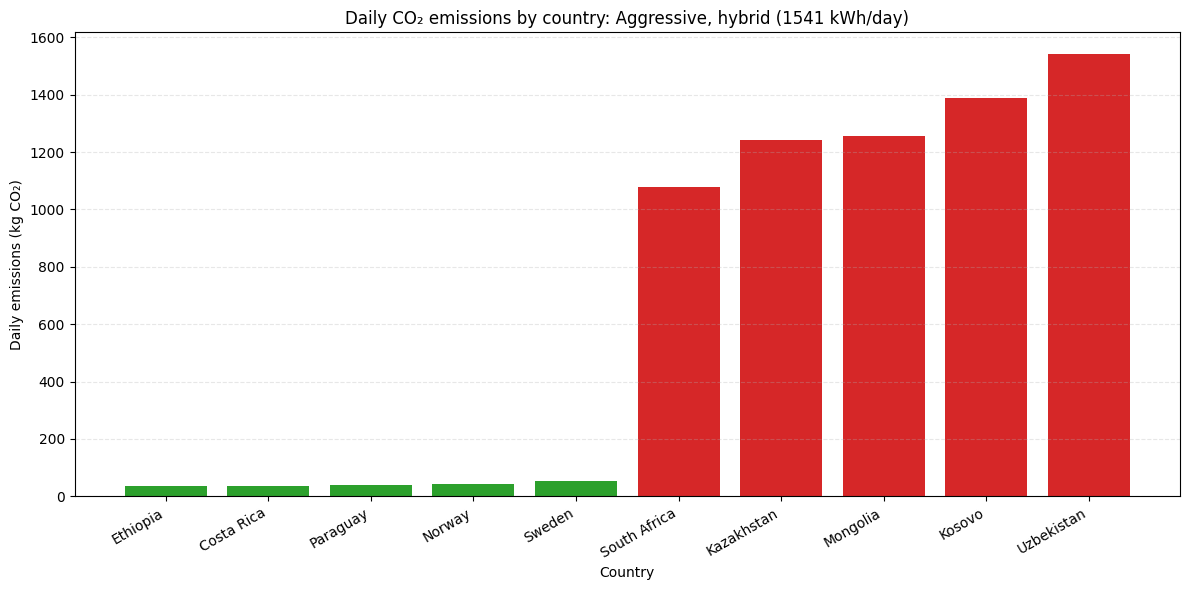

--- CI year used: 2025 ---
     country      ci  daily_kgco2
    Ethiopia   23.08    35.554998
  Costa Rica   24.20    37.280371
    Paraguay   24.70    38.050626
      Norway   28.11    43.303769
      Sweden   35.26    54.318424
South Africa  699.29  1077.264067
  Kazakhstan  805.32  1240.604468
    Mongolia  816.31  1257.534686
      Kosovo  900.94  1387.908148
  Uzbekistan 1000.00  1540.511186


In [ ]:
# --- Block 5: Country Carbon Intensity Comparison (Best 5 + Worst 5) ---
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the dataframe loaded in the previous cell (with browser headers).
# If that cell has not run, fall back to a direct pd.read_csv call.
try:
    df_ci  # noqa: F821
except NameError:
    df_ci = pd.read_csv(
        "https://ourworldindata.org/grapher/carbon-intensity-electricity.csv"
        "?v=1&csvType=full&useColumnShortNames=false"
    )

# Rename columns to short names
df_ci = df_ci.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Carbon intensity of electricity per kWh": "ci",
})

# Drop missing values
df_ci = df_ci.dropna(subset=["ci"])

# Take the latest available year
latest_year = df_ci["year"].max()
df_latest = df_ci[df_ci["year"] == latest_year].copy()

# Remove regional aggregates so we are left with countries only
exclude_entities = {
    "World", "Asia", "Africa", "Europe", "North America", "South America",
    "European Union", "OECD", "G20", "G7", "ASEAN",
}
df_latest = df_latest[~df_latest["country"].isin(exclude_entities)]

# Top 5 cleanest and top 5 dirtiest grids by CI
df_sorted = df_latest.sort_values("ci")
df_best   = df_sorted.head(5)
df_worst  = df_sorted.tail(5)
df_plot   = pd.concat([df_best, df_worst])

# Use the strategy / arrival_mode totals computed earlier
# (re-run Block 4 if you switch strategies)
# Convert daily kWh to daily kgCO2 for each country in df_plot
daily_kwh = total_kwh  # from Block 4
df_plot = df_plot.copy()
df_plot["daily_kgco2"] = (df_plot["ci"] * daily_kwh) / 1000

# Plot
plt.figure(figsize=(12, 6))
colors = ['#2ca02c'] * len(df_best) + ['#d62728'] * len(df_worst)
plt.bar(df_plot["country"], df_plot["daily_kgco2"], color=colors)
plt.title(f'Daily CO\u2082 emissions by country: '
          f'{strategy_mode}, {arrival_mode} ({daily_kwh:.0f} kWh/day)')
plt.xlabel('Country')
plt.ylabel('Daily emissions (kg CO\u2082)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "country_carbon_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"--- CI year used: {latest_year} ---")
print(df_plot[["country", "ci", "daily_kgco2"]].to_string(index=False))
